# Data Exploration Before Cleaning

### Imports

In [1]:
#!pip install pandas numpy matplotlib seaborn scikit-learn emot

In [2]:
import re
import html
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from dateutil import tz
from collections import Counter
from matplotlib.patches import Patch
from emot.emo_unicode import EMOTICONS_EMO
from sklearn.feature_extraction.text import CountVectorizer

## Loading Dataset

In [3]:
df = pd.read_csv("../data/raw/training.1600000.processed.noemoticon.csv",
                encoding="latin-1",header=None,
                names=["sentiment", "id", "date", "query", "user", "tweet"])

## 1. Basic Data Exploration

### Head and Shape

In [4]:
df.head()

,sentiment,id,date,query,user,tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df.shape

(1600000, 6)

### Checking Data Types and Null Columns

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   sentiment  1600000 non-null  int64
 1   id         1600000 non-null  int64
 2   date       1600000 non-null  str  
 3   query      1600000 non-null  str  
 4   user       1600000 non-null  str  
 5   tweet      1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 256.9 MB


### Removing Duplicate Rows 

In [7]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (1600000, 6)
After: (1600000, 6)


### Reassigning Sentiment Values 

In [8]:
df["sentiment"] = df["sentiment"].replace({0:0, 4:1})

### Checking for Class Imbalance

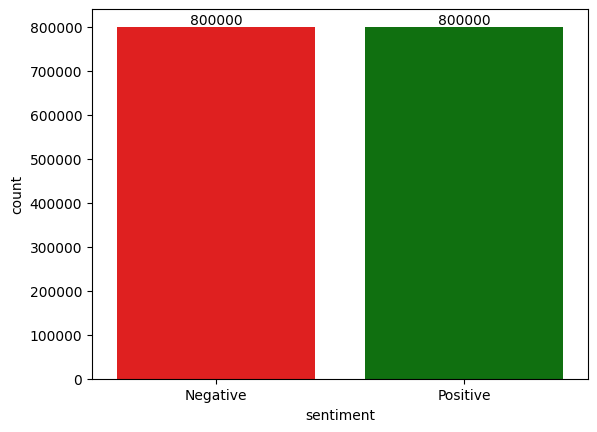

In [9]:
sentiment_counts = df["sentiment"].value_counts().reset_index()
sentiment_counts["sentiment"] = sentiment_counts["sentiment"].replace({0:"Negative", 1:"Positive"})

ax = sns.barplot(
    data=sentiment_counts,
    x="sentiment", y="count",
    hue="sentiment",
    palette={"Positive":"green","Negative":"red"}
)
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Basic Statistics Using Describe

In [10]:
df.describe()

,sentiment,id
count,1600000.0,1.600000e+06
mean,0.5,1.998818e+09
std,0.5,1.935761e+08
min,0.0,1.467810e+09
25%,0.0,1.956916e+09
50%,0.5,2.002102e+09
75%,1.0,2.177059e+09
max,1.0,2.329206e+09


In [11]:
df.describe(include="str")

,date,query,user,tweet
count,1600000,1600000,1600000,1600000
unique,774363,1,659775,1581466
top,Mon Jun 15 12:53:14 PDT 2009,NO_QUERY,lost_dog,isPlayer Has Died! Sorry
freq,20,1600000,549,210


## 2. Exploring Tweets

### Random 5 Positive and Negative Sentiment Tweets 

In [12]:
df[df["sentiment"] == 0]["tweet"].sample(5).values

<ArrowStringArray>
['Rates won't be this low for much longer - the time to refi into a VERY low rate may be coming to an end!!     Call before they raise them!',
                                                                                                                       'Doing laundry...boo ',
                                                                  '@danisays ha! I'm done and you aren't.  I feel weird without my bracelet ',
                                                                                                                              'im not ready ',
                 'OMG .. The new American Idol is SMOKIN' HOTT!! .. Too bad he's married  .. Not too worried cuz I still have David Cook! ..']
Length: 5, dtype: str

In [13]:
df[df["sentiment"] == 1]["tweet"].sample(5).values

<ArrowStringArray>
[                                                    '@fadedmoon oh. Why never thought of it?  'cause she can't do english well. joke xP',
                                                     '@ktjlarsen Sweet thanks! Maybe I'll have to get caught up between #ChuckMeMondays ',
 '@NorfolkForDogs are you talking about the Kerry Greyhounds show? I was talking about new show at Rennowe park www.norfolkdogday.co.uk ',
                                                                                                         'I got new shoes  They're cute.',
                                                                                        '@MalaReignz Thanks, Enjoy your dinner tomorrow ']
Length: 5, dtype: str

### Counting Characters and Words in the Tweets

In [14]:
df["char_count"] = df["tweet"].str.replace(r"\s+", "", regex=True).str.len()
df["word_count"] = df["tweet"].str.split().str.len()
df[["tweet", "char_count", "word_count"]].head()

,tweet,char_count,word_count
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",96,19
1,is upset that he can't update his Facebook by ...,90,21
2,@Kenichan I dived many times for the ball. Man...,71,18
3,my whole body feels itchy and like its on fire,37,10
4,"@nationwideclass no, it's not behaving at all....",90,21


#### Plotting Charecter Count Distributions

In [15]:
min_val = df["char_count"].min()
max_val = df["char_count"].max()
mean_val = df["char_count"].mean()
median_val = df["char_count"].median()

df_neg = df[df["sentiment"] == 0]
min_neg = df_neg["char_count"].min()
max_neg = df_neg["char_count"].max()
mean_neg = df_neg["char_count"].mean()
median_neg = df_neg["char_count"].median()

df_pos = df[df["sentiment"] == 1]
min_pos = df_pos["char_count"].min()
max_pos = df_pos["char_count"].max()
mean_pos = df_pos["char_count"].mean()
median_pos = df_pos["char_count"].median()

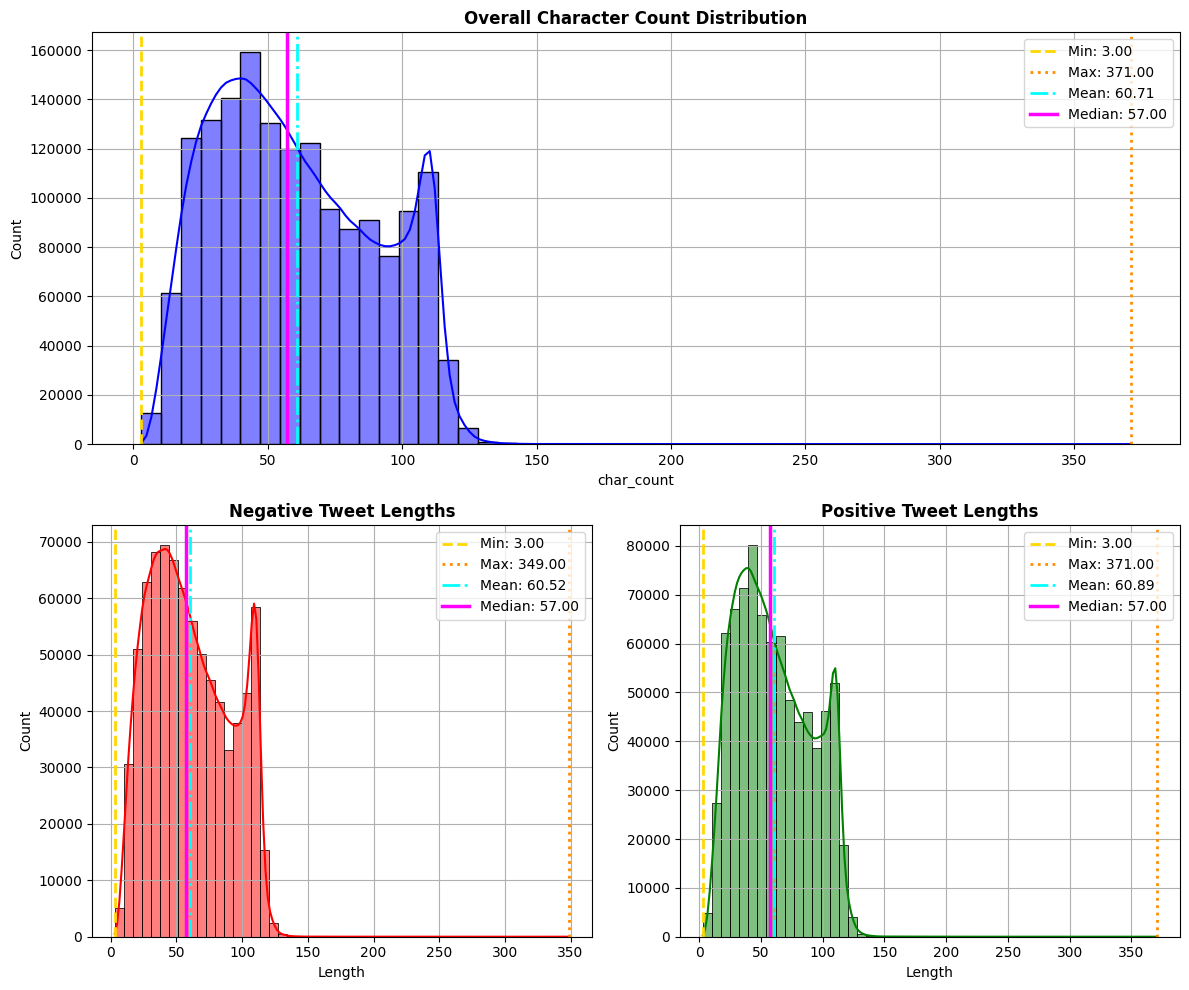

In [16]:
fig = plt.figure(figsize=(12,10))
ax_top = plt.subplot2grid((2, 2), (0, 0), colspan=2)  # Row 0, spans both columns
ax_neg = plt.subplot2grid((2, 2), (1, 0))  # Row 1, Column 0
ax_pos = plt.subplot2grid((2, 2), (1, 1))  # Row 1, Column 1


# row1: overall distribution
sns.histplot(data=df, x="char_count", bins=50, kde=True, color="blue", ax=ax_top)
ax_top.set_title("Overall Character Count Distribution", fontweight="bold")

ax_top.axvline(x=min_val, color="#FFD700", linestyle="--", linewidth=2, label=f"Min: {min_val:.2f}")        # Crisp Red
ax_top.axvline(x=max_val, color="#FF8C00", linestyle=":", linewidth=2, label=f"Max: {max_val:.2f}")        # Deep Navy
ax_top.axvline(x=mean_val, color="#00FFFF", linestyle="-.", linewidth=2, label=f"Mean: {mean_val:.2f}")     # Slate Blue
ax_top.axvline(x=median_val, color="#FF00FF", linestyle="-", linewidth=2.5, label=f"Median: {median_val:.2f}") # Soft Teal


ax_top.legend(loc="upper right")
ax_top.grid(True)


# row2: left: negative sentiment distribution
sns.histplot(
    data=df_neg, x="char_count", bins=50, kde=True, color="red", ax=ax_neg
)
ax_neg.set_title("Negative Tweet Lengths", fontweight="bold")
ax_neg.set_xlabel("Length")

ax_neg.axvline(x=min_neg, color="#FFD700", linestyle="--", linewidth=2, label=f"Min: {min_neg:.2f}")
ax_neg.axvline(x=max_neg, color="#FF8C00", linestyle=":", linewidth=2, label=f"Max: {max_neg:.2f}")
ax_neg.axvline(x=mean_neg, color="#00FFFF", linestyle="-.", linewidth=2, label=f"Mean: {mean_neg:.2f}")
ax_neg.axvline(x=median_neg, color="#FF00FF", linestyle="-", linewidth=2.5, label=f"Median: {median_neg:.2f}")


ax_neg.legend(loc="upper right")
ax_neg.grid(True)


# row2: right: positive sentiment distribution
sns.histplot(
    data=df_pos, x="char_count", bins=50, kde=True, color="green", ax=ax_pos
)
ax_pos.set_title("Positive Tweet Lengths", fontweight="bold")
ax_pos.set_xlabel("Length")

ax_pos.axvline(x=min_pos, color="#FFD700", linestyle="--", linewidth=2, label=f"Min: {min_pos:.2f}")
ax_pos.axvline(x=max_pos, color="#FF8C00", linestyle=":", linewidth=2, label=f"Max: {max_pos:.2f}")
ax_pos.axvline(x=mean_pos, color="#00FFFF", linestyle="-.", linewidth=2, label=f"Mean: {mean_pos:.2f}")
ax_pos.axvline(x=median_pos, color="#FF00FF", linestyle="-", linewidth=2.5, label=f"Median: {median_pos:.2f}")


ax_pos.legend(loc="upper right")
ax_pos.grid(True)

plt.tight_layout()
plt.show()

#### Plotting Word Count Distributions

In [17]:
min_val = df["word_count"].min()
max_val = df["word_count"].max()
mean_val = df["word_count"].mean()
median_val = df["word_count"].median()

df_neg = df[df["sentiment"] == 0]
min_neg = df_neg["word_count"].min()
max_neg = df_neg["word_count"].max()
mean_neg = df_neg["word_count"].mean()
median_neg = df_neg["word_count"].median()

df_pos = df[df["sentiment"] == 1]
min_pos = df_pos["word_count"].min()
max_pos = df_pos["word_count"].max()
mean_pos = df_pos["word_count"].mean()
median_pos = df_pos["word_count"].median()

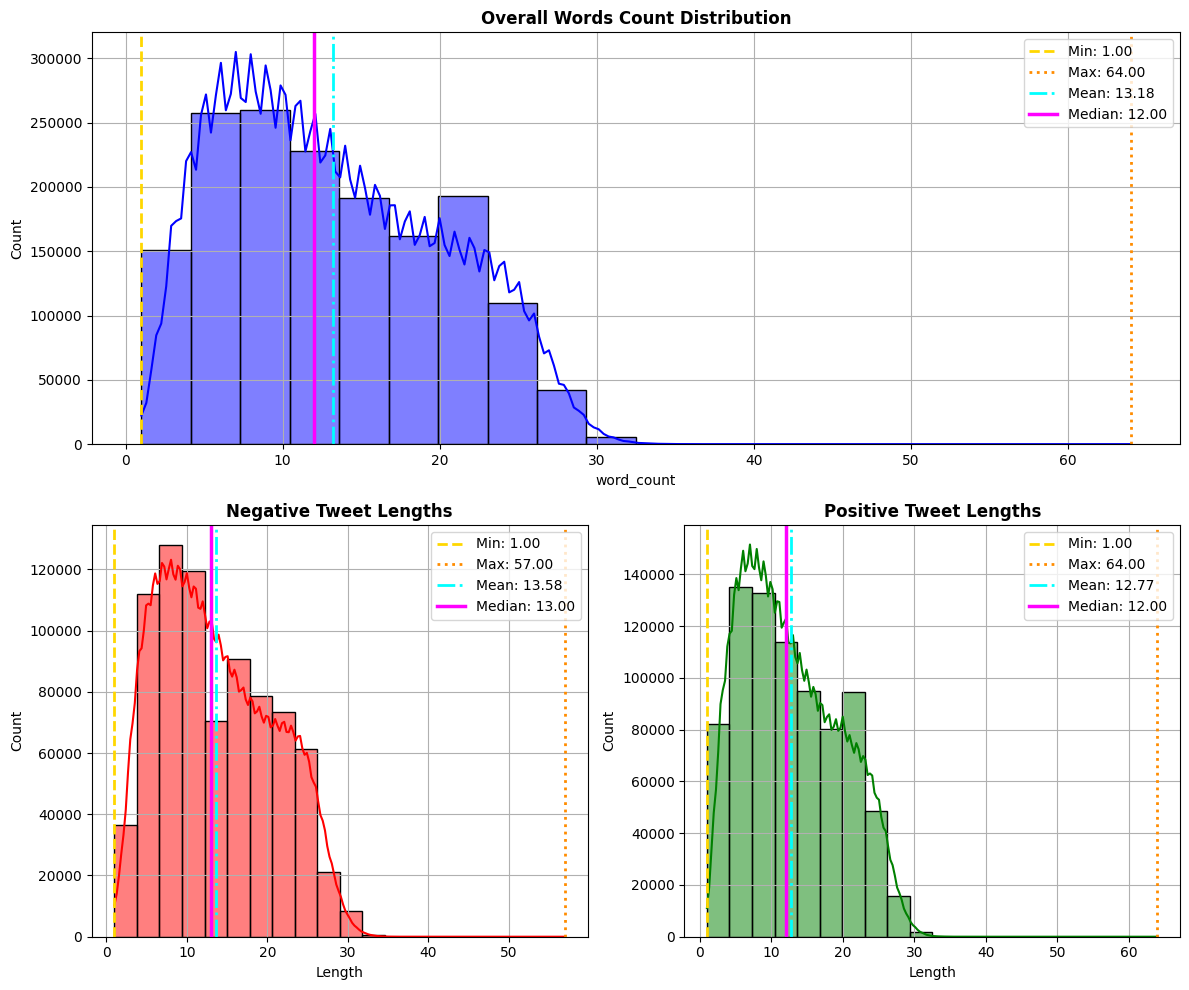

In [18]:
fig = plt.figure(figsize=(12,10))
ax_top = plt.subplot2grid((2, 2), (0, 0), colspan=2)  # Row 0, spans both columns
ax_neg = plt.subplot2grid((2, 2), (1, 0))  # Row 1, Column 0
ax_pos = plt.subplot2grid((2, 2), (1, 1))  # Row 1, Column 1


# row1: overall distribution
sns.histplot(data=df, x="word_count", bins=20, kde=True, color="blue", ax=ax_top)
ax_top.set_title("Overall Words Count Distribution", fontweight="bold")

ax_top.axvline(x=min_val, color="#FFD700", linestyle="--", linewidth=2, label=f"Min: {min_val:.2f}")        # Crisp Red
ax_top.axvline(x=max_val, color="#FF8C00", linestyle=":", linewidth=2, label=f"Max: {max_val:.2f}")        # Deep Navy
ax_top.axvline(x=mean_val, color="#00FFFF", linestyle="-.", linewidth=2, label=f"Mean: {mean_val:.2f}")     # Slate Blue
ax_top.axvline(x=median_val, color="#FF00FF", linestyle="-", linewidth=2.5, label=f"Median: {median_val:.2f}") # Soft Teal


ax_top.legend(loc="upper right")
ax_top.grid(True)


# row2: left: negative sentiment distribution
sns.histplot(
    data=df_neg, x="word_count", bins=20, kde=True, color="red", ax=ax_neg
)
ax_neg.set_title("Negative Tweet Lengths", fontweight="bold")
ax_neg.set_xlabel("Length")

ax_neg.axvline(x=min_neg, color="#FFD700", linestyle="--", linewidth=2, label=f"Min: {min_neg:.2f}")
ax_neg.axvline(x=max_neg, color="#FF8C00", linestyle=":", linewidth=2, label=f"Max: {max_neg:.2f}")
ax_neg.axvline(x=mean_neg, color="#00FFFF", linestyle="-.", linewidth=2, label=f"Mean: {mean_neg:.2f}")
ax_neg.axvline(x=median_neg, color="#FF00FF", linestyle="-", linewidth=2.5, label=f"Median: {median_neg:.2f}")


ax_neg.legend(loc="upper right")
ax_neg.grid(True)


# row2: right: positive sentiment distribution
sns.histplot(
    data=df_pos, x="word_count", bins=20, kde=True, color="green", ax=ax_pos
)
ax_pos.set_title("Positive Tweet Lengths", fontweight="bold")
ax_pos.set_xlabel("Length")

ax_pos.axvline(x=min_pos, color="#FFD700", linestyle="--", linewidth=2, label=f"Min: {min_pos:.2f}")
ax_pos.axvline(x=max_pos, color="#FF8C00", linestyle=":", linewidth=2, label=f"Max: {max_pos:.2f}")
ax_pos.axvline(x=mean_pos, color="#00FFFF", linestyle="-.", linewidth=2, label=f"Mean: {mean_pos:.2f}")
ax_pos.axvline(x=median_pos, color="#FF00FF", linestyle="-", linewidth=2.5, label=f"Median: {median_pos:.2f}")


ax_pos.legend(loc="upper right")
ax_pos.grid(True)

plt.tight_layout()
plt.show()

### Top N Most Common Words

#### Most Common Words

In [19]:
n = 20
sample_size = 100000

words = Counter()
for tweet in df["tweet"].sample(sample_size):
    words.update(re.findall(r"\w+", tweet.lower()))

top_n = words.most_common(n)
words_df = pd.DataFrame(top_n, columns=["Word", "Count"])

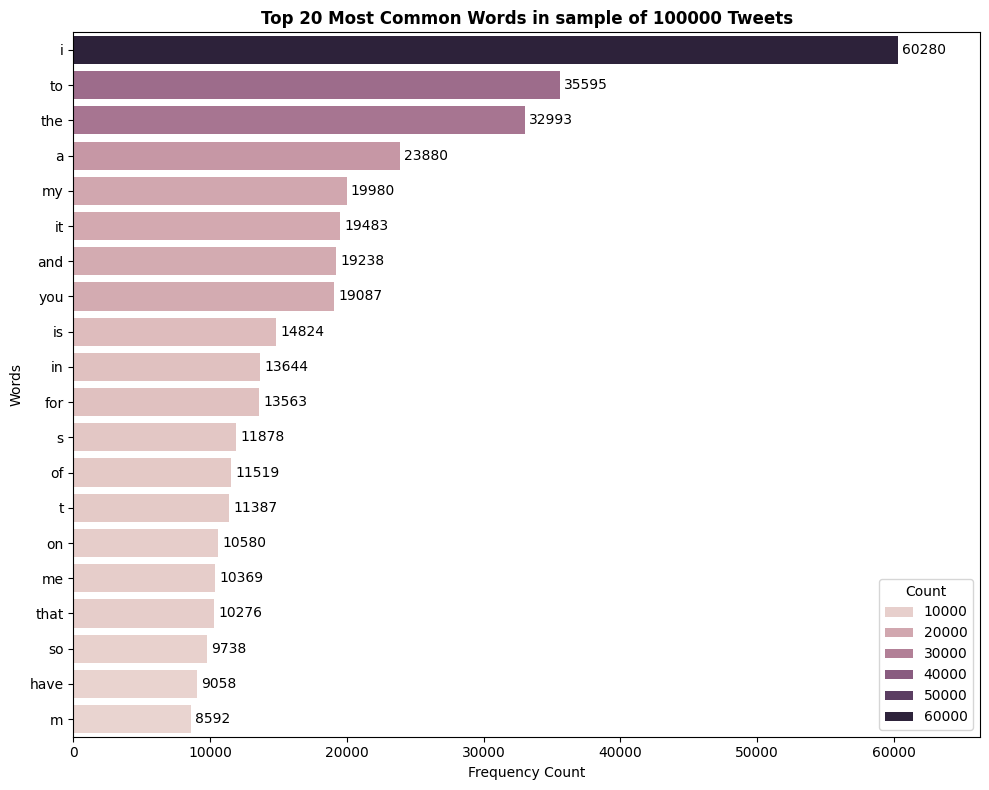

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=words_df,
    x="Count",
    y="Word",
    hue="Count",
    ax=ax,
)

ax.set_title(
    f"Top {n} Most Common Words in sample of {sample_size} Tweets",
    fontweight="bold",
)
ax.set_xlabel("Frequency Count")
ax.set_ylabel("Words")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_xlim(0, words_df["Count"].max() * 1.1)

plt.tight_layout()
plt.show()

#### Most Common Words in Positive Tweets

In [21]:
df_pos = df[df["sentiment"] == 1]["tweet"].sample(sample_size)
words = Counter()
for tweet in df_pos:
    words.update(re.findall(r"\w+", tweet.lower()))

top_n = words.most_common(n)
words_df = pd.DataFrame(top_n, columns=["Word", "Count"])

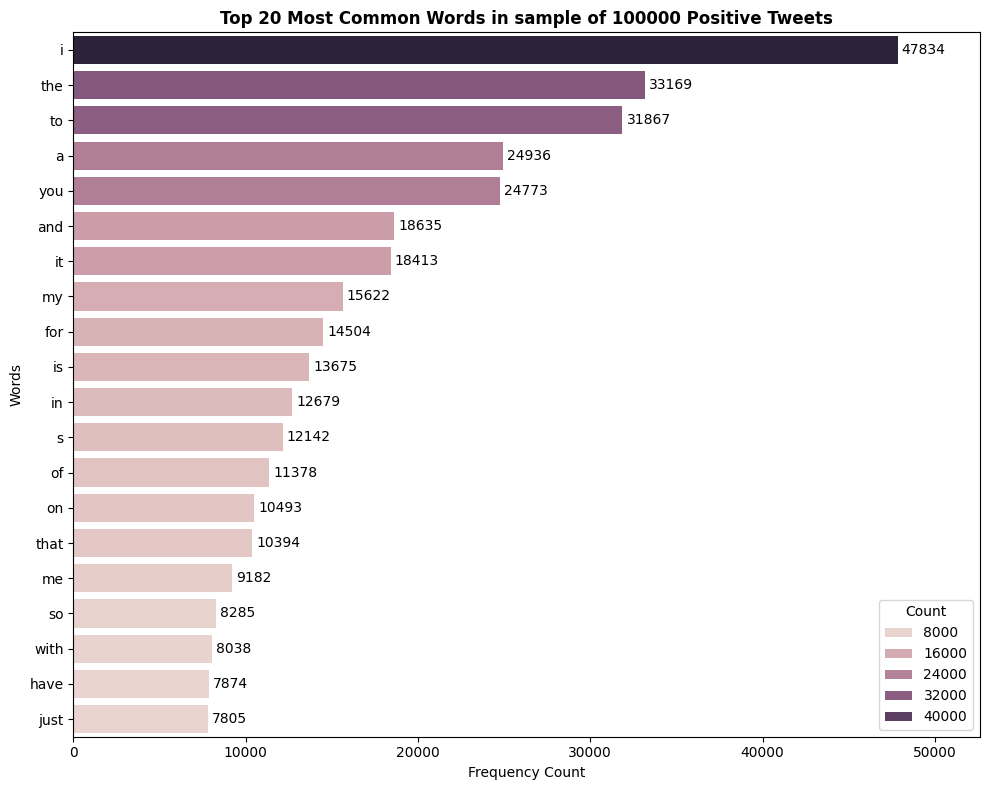

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=words_df,
    x="Count",
    y="Word",
    hue="Count",
    ax=ax,
)

ax.set_title(
    f"Top {n} Most Common Words in sample of {sample_size} Positive Tweets",
    fontweight="bold",
)
ax.set_xlabel("Frequency Count")
ax.set_ylabel("Words")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_xlim(0, words_df["Count"].max() * 1.1)

plt.tight_layout()
plt.show()

#### Most Common Words in Negative Tweets

In [23]:
df_neg = df[df["sentiment"] == 0]["tweet"].sample(sample_size)
words = Counter()
for tweet in df_neg:
    words.update(re.findall(r"\w+", tweet.lower()))

top_n = words.most_common(n)
words_df = pd.DataFrame(top_n, columns=["Word", "Count"])

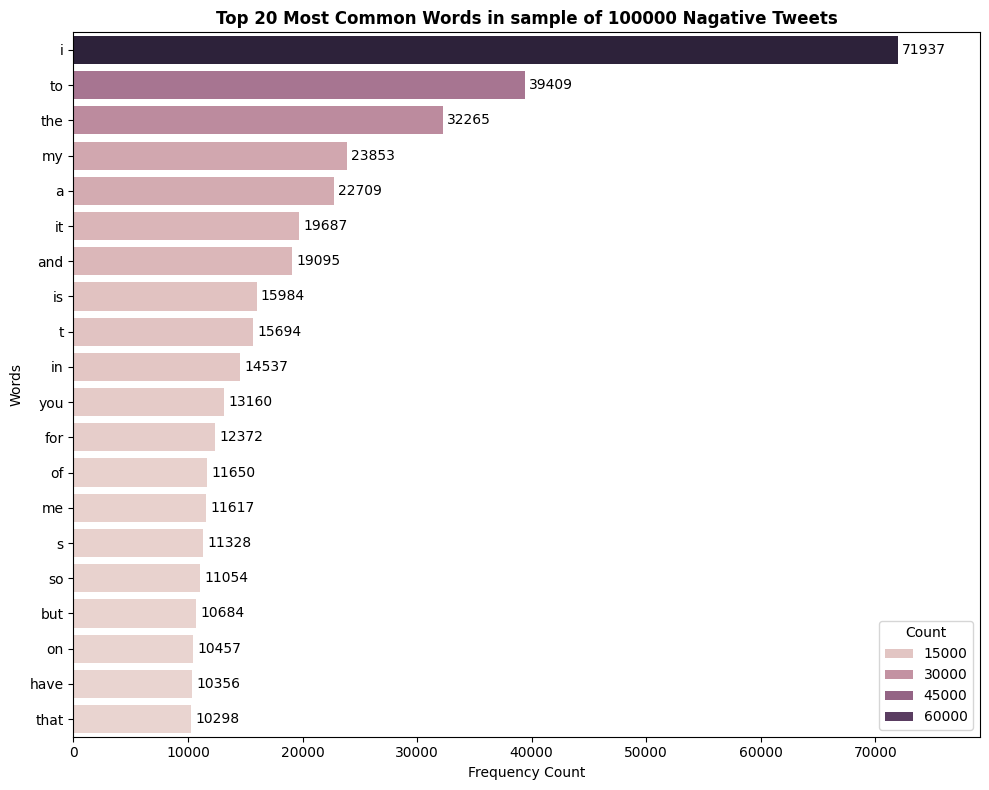

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=words_df,
    x="Count",
    y="Word",
    hue="Count",
    ax=ax,
)

    
ax.set_title(
    f"Top {n} Most Common Words in sample of {sample_size} Nagative Tweets",
    fontweight="bold",
)
ax.set_xlabel("Frequency Count")
ax.set_ylabel("Words")
        
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
    
ax.set_xlim(0, words_df["Count"].max() * 1.1)

plt.tight_layout()
plt.show()

### Total Number of Tweets Containing URLs, Mentions, and Hashtags

In [25]:
df["url_count"] = df["tweet"].apply(lambda x: len(re.findall(r"https?://\S+|www\.\S+", str(x))))
df["mention_count"] = df["tweet"].apply(lambda x: len(re.findall(r"@\w+", str(x))))
df["hashtag_count"] = df["tweet"].apply(lambda x: len(re.findall(r"#\w+", str(x))))

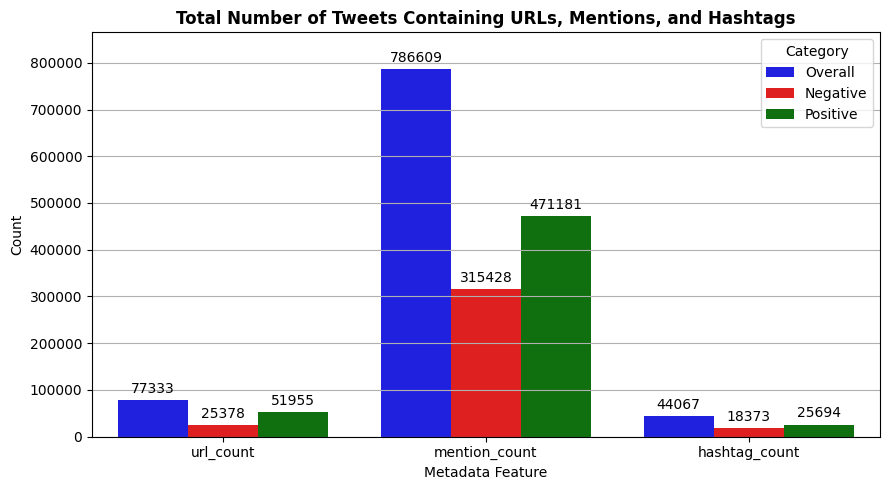

In [26]:
def plot_summary(features, title, xlabel):
    counts = []
    for f in features:
        if f == "Tweets with Emoticons":
            counts.extend([len(df[df["emoticon_count"] > 0]), 
                           len(df[(df["emoticon_count"] > 0) & (df["sentiment"] == 0)]), 
                           len(df[(df["emoticon_count"] > 0) & (df["sentiment"] == 1)])])
        else:
            counts.extend([df[f].sum(), df[df["sentiment"] == 0][f].sum(), df[df["sentiment"] == 1][f].sum()])
            
    plot_df = pd.DataFrame({
        "Feature": sum([[f]*3 for f in features], []),
        "Category": ["Overall", "Negative", "Positive"] * len(features),
        "Count": counts
    })
    
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=plot_df, x="Feature", y="Count", hue="Category", 
                     palette={"Overall": "blue", "Negative": "red", "Positive": "green"})
    
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.grid(axis="y")
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    ax.set_ylim(0, plot_df["Count"].max() * 1.1)

    plt.tight_layout()
    plt.show()


plot_summary(["url_count", "mention_count", "hashtag_count"], "Total Number of Tweets Containing URLs, Mentions, and Hashtags", "Metadata Feature")

### Total Number of Tweets Containing !, and Capital Words

In [27]:
df["excl_count"] = df["tweet"].apply(lambda x: str(x).count("!"))
df["caps_count"] = df["tweet"].apply(lambda x: len([w for w in str(x).split() if w.isupper() and len(w) > 1]))

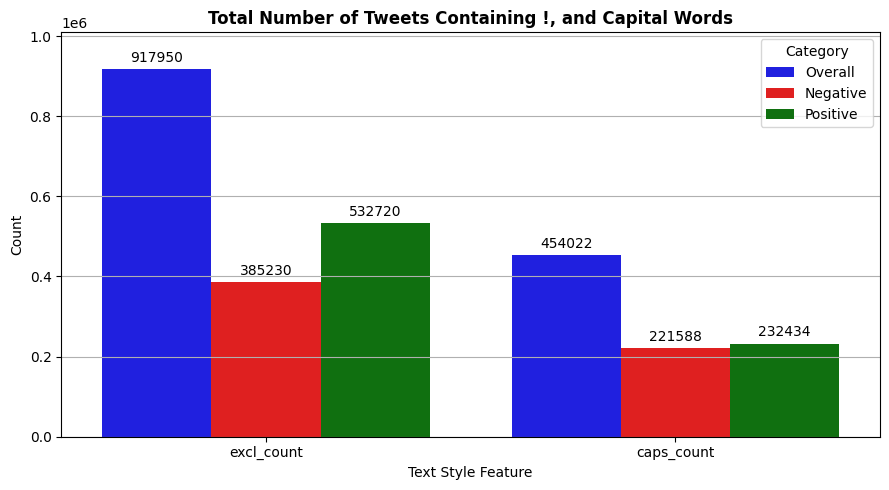

In [28]:
plot_summary(["excl_count", "caps_count"], "Total Number of Tweets Containing !, and Capital Words", "Text Style Feature")

### Total Number of Tweets Containing Emoticons

In [29]:
emoticon_patterns = sorted(EMOTICONS_EMO.keys(), key=len, reverse=True)
emot_regex = re.compile("(" + "|".join(re.escape(emot) for emot in emoticon_patterns) + ")")
df["emoticon_count"] = df["tweet"].apply(lambda x: len(emot_regex.findall(str(x))))

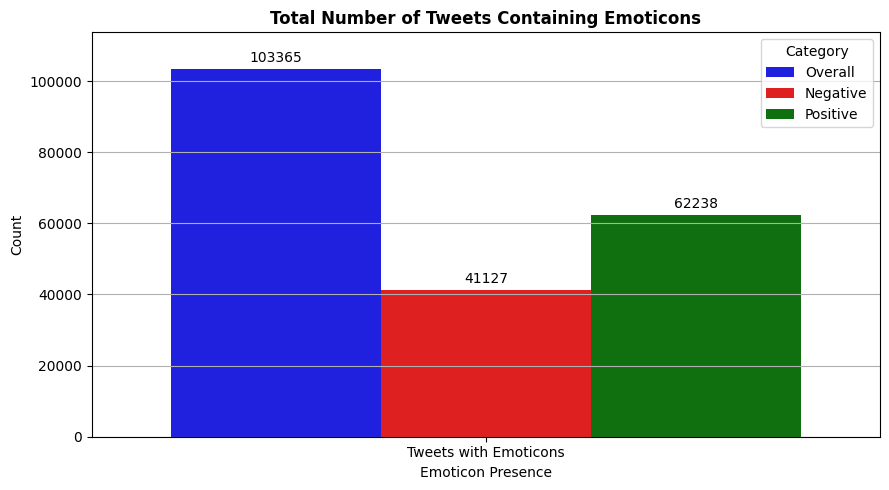

In [30]:
plot_summary(["Tweets with Emoticons"], "Total Number of Tweets Containing Emoticons", "Emoticon Presence")

### Average emoticon count per sentiment

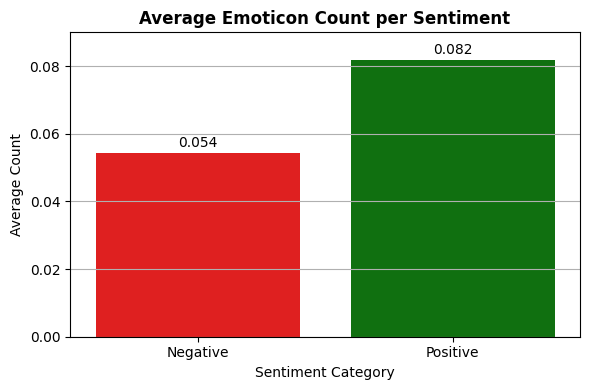

In [31]:
avg_emoticon_df = df.groupby("sentiment")["emoticon_count"].mean().reset_index()
avg_emoticon_df.columns = ["Sentiment", "Average Emoticon Count"]
avg_emoticon_df["Sentiment"] = avg_emoticon_df["Sentiment"].map({0: "Negative", 1: "Positive"})

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=avg_emoticon_df, 
    x="Sentiment", 
    y="Average Emoticon Count", 
    hue="Sentiment",
    palette={"Negative": "red", "Positive": "green"}
)

ax.set_title("Average Emoticon Count per Sentiment", fontweight="bold")
ax.set_xlabel("Sentiment Category")
ax.set_ylabel("Average Count")
ax.grid(axis="y")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)
    
ax.set_ylim(0, avg_emoticon_df["Average Emoticon Count"].max() * 1.1)

plt.tight_layout()
plt.show()

### Bigrams and Trigrams (N-Grams)

In [32]:
def get_top_ngrams(corpus, ngram_range):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq, columns=["N-Gram", "Count"])

In [33]:
def plot_ngrams(ngram_df, plot_title):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.barplot(
        data=ngram_df,
        x="Count",
        y="N-Gram",
        hue="Count",
        ax=ax,
    )
    
    ax.set_title(
        plot_title,
        fontweight="bold",
    )
    ax.set_xlabel("Frequency Count")
    ax.set_ylabel("Words")
    
    ax.set_xlim(0, words_df["Count"].max() * 1.1)
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)
        
    plt.tight_layout()
    plt.show()

In [34]:
bg_df = get_top_ngrams(df["tweet"].astype(str), ngram_range=(2, 2))

In [35]:
tg_df = get_top_ngrams(df["tweet"].astype(str), ngram_range=(3, 3))

In [36]:
top_n=10

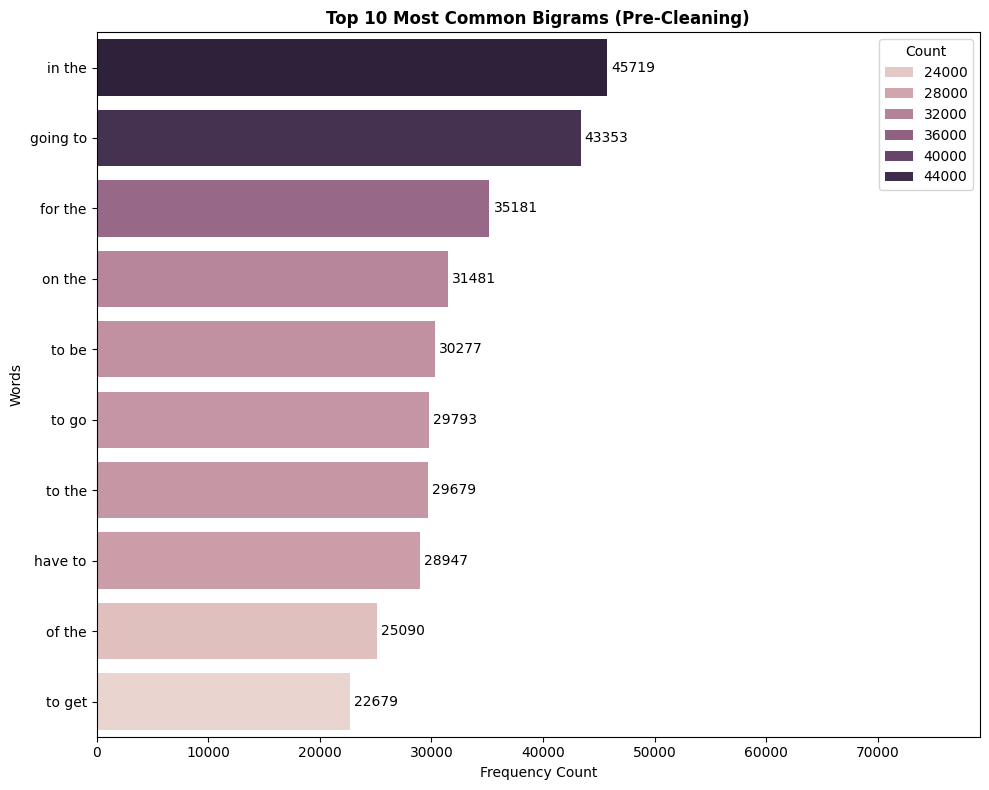

In [37]:
plot_ngrams(bg_df.head(top_n), f"Top {top_n} Most Common Bigrams (Pre-Cleaning)")

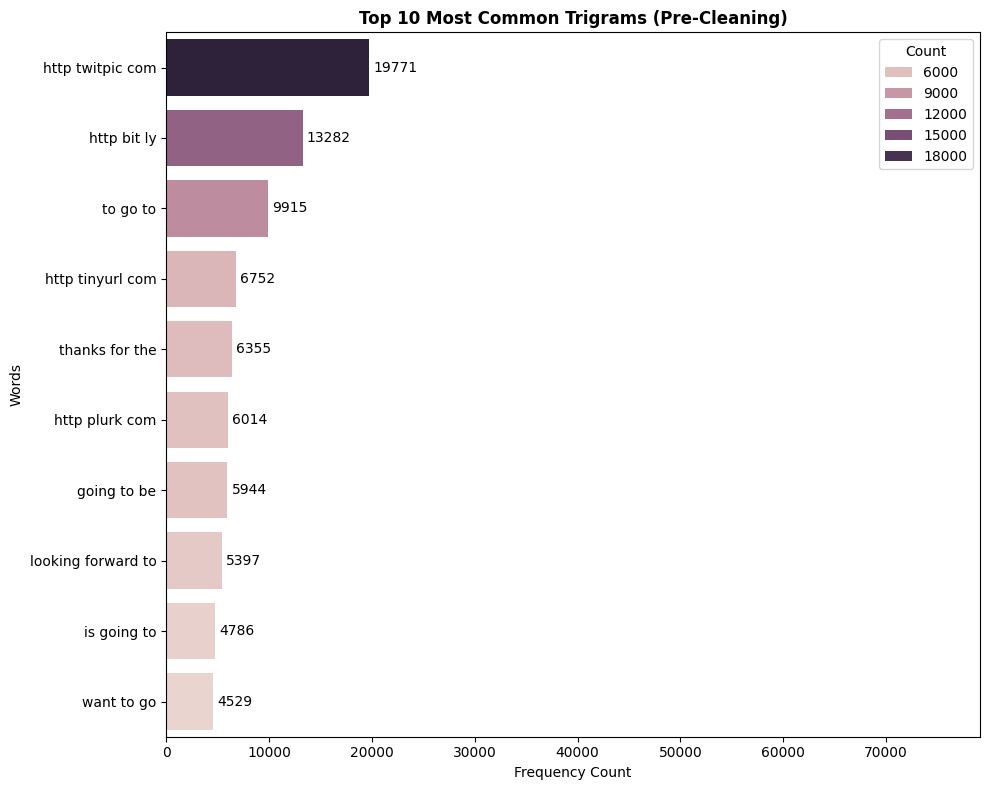

In [38]:
plot_ngrams(tg_df.head(top_n), f"Top {top_n} Most Common Trigrams (Pre-Cleaning)")

### Vocabulary Size (Cardinality)

In [39]:
vec = CountVectorizer().fit(df["tweet"].astype(str))

In [40]:
unique_words = len(vec.vocabulary_)
total_words = df["tweet"].astype(str).str.split().str.len().sum()
lexical_diversity = unique_words / total_words if total_words > 0 else 0

In [41]:
print(f"Total Words Processed: {total_words:,}")
print(f"Unique Words (Vocabulary Size): {unique_words:,}")
print(f"Lexical Diversity Ratio: {lexical_diversity:.6f}")

Total Words Processed: 21,081,841
Unique Words (Vocabulary Size): 684,358
Lexical Diversity Ratio: 0.032462
